In [33]:

# !kaggle datasets download warcoder/infant-cry-audio-corpus
# !kaggle datasets download mennaahmed23/baby-crying-sounds-dataset

# !wget https://osf.io/ru7na/overview/audio_EnesBabyCries1B_cries.zip
# !wget https://osf.io/ru7na/overview/data.zip


In [34]:
# !unzip infant-cry-audio-corpus.zip
# !unzip /content/infant-cry-audio-corpus.zip
# !unzip /content/baby-crying-sounds-dataset.zip
# !unzip audio_EnesBabyCries1B_cries.zip
# !unzip data.zip

In [35]:
import torch
import torchaudio
import torch.nn as nn
import numpy as np
import librosa
import torchvision.datasets
import torch.nn.functional as F
from torch.utils.data import Subset
from torch.utils.data import DataLoader
from torch.nn.modules.flatten import Flatten
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

print("Device:", device)

Device: mps


In [36]:
# various constants
import os

h={}
h["device"] = str(device)
h["max_audio_seconds"]= 7
h["sample_rate"]= 16000 # all files appear to be 8k
h["batch_size"] = 100
h["learning_rate"] = .001
h["num_epochs"] = 20
h["weight_decay"] = 1e-4
h["stft_frame_length"] = 1024
h["stft_frame_step"] = 320
h["n_mels"] = 128
h["mel_fmin"] = 120
h["mel_fmax"] = h["sample_rate"] / 2

import torch
import numpy as np
torch.manual_seed(42)
np.random.seed(42)



In [37]:
def slice_waveform(waveform, max_length):
    """
    Slices a waveform tensor into segments of max_length. If the waveform is at least 1.5 times max_length,
    it will be split into segments of max_length, and only segments at least half max_length are kept.
    Each segment is not padded or truncated here; just sliced as is.
    Args:
        waveform (Tensor): shape (channels, samples)
        max_length (int): target segment length in samples
    Returns:
        list of waveform segments (Tensor), or [waveform] if no slicing needed
    """
    min_length = int(0.5 * max_length)
    max_slice_length = int(1.5 * max_length)
    total_length = waveform.shape[1]
    slices = []
    start = 0
    # Only slice if waveform is at least 1.5x max_length
    if total_length >= max_slice_length:
        while total_length - start >= max_slice_length:
            end = start + max_length
            slices.append(waveform[:, start:end])
            start += max_length
        # Add the last slice if it's at least half the target length
        if total_length - start >= min_length:
            end = min(start + max_length, total_length)
            slices.append(waveform[:, start:end])
        return slices
    else:
        return [waveform]

In [38]:
# Enums and dictionaries for indexing and mapping
from enum import IntEnum
class data_tensor_index(IntEnum):
    SPEC = 0,
    WAV = 1
    SR = 2,
    FILE_NAME = 3,
    CRY_TYPE = 4
    AGE=5,
    GENDER=6,

age_dict ={'04':'0 to 4 weeks old',
                 '48':'4 to 8 weeks old',
                 '26': '2 to 6 months old',
                 '72': '7 month to 2 years old',
                 '22':'more than 2 years old'}

# Existing code mapping 
cry_type_dict = {
    'bu': 'burp',
    'hu': 'hunger',
    'ch': 'cold/hot',
    'ti': 'tired',
    'bp': 'belly pain',
    'dc': 'discomfort',
    'dk': "dk",
    'lo': 'loneliness',
    'sc': 'scared',
    'ot': 'other',
    'pn': 'pain',
    'none': 'unknown',
    'NoneType': 'unknown',
}

def map_age_to_code(age_month):
    """
    Map age in months to age_dict code.
    """
    try:
        age = float(age_month)
    except (ValueError, TypeError):
        return None
    if age < 1:
        return '04'  # 0 to 4 weeks
    elif 1 <= age < 2:
        return '48'  # 4 to 8 weeks
    elif 2 <= age < 7:
        return '26'  # 2 to 6 months
    elif 7 <= age < 24:
        return '72'  # 7 months to 2 years
    elif age >= 24:
        return '22'  # more than 2 years
    else:
        return None

In [39]:
# Audio loading and processing functions
from os.path import isfile
import matplotlib

# Helper Functions
import torchaudio
from pathlib import Path

def plot_spectogram(spec):
    import matplotlib.pyplot as plt

    # Let's plot the mel spectrogram
    plt.figure(figsize=(10, 4))
    plt.imshow(spec[0].detach().numpy(), aspect="auto", origin="lower")
    plt.title("Mel spectrogram")
    plt.xlabel("Frames")
    plt.ylabel("Frequency")
    # plt.colorbar()
    plt.show()

def display_audio(wav):
    from IPython.display import Audio, display
    display(Audio(wav.detach().numpy(), rate=h["sample_rate"]))

def compute_spectrogram(wav, sample_rate, use_log_mel_pcen=False):

    # we use librosa's mel() function to create the mel filterbank
    mel = librosa.filters.mel(sr=h["sample_rate"], n_fft=h["stft_frame_length"], n_mels=h["n_mels"], fmin=h["mel_fmin"], fmax=h["mel_fmax"])
    mel = torch.from_numpy(mel).float()

    # We create a Hann window of size win_size.
    # The Hann window is used to smooth the signal before applying the STFT.
    hann_window = torch.hann_window(h["stft_frame_length"])

    # We pad the audio signal to make sure that the length is a multiple of hop_size
    wav = torch.nn.functional.pad(wav, (int((h["stft_frame_length"]- h["stft_frame_step"]) / 2), int((h["stft_frame_length"]- h["stft_frame_step"]) / 2)), mode="reflect")
    wav = wav.squeeze(1)

    # We compute the STFT of the audio signal
    spec = torch.view_as_real(torch.stft(wav, h["stft_frame_length"], hop_length=h["stft_frame_step"], win_length=h["stft_frame_length"], window=hann_window,
                      center=False, pad_mode="reflect", normalized=False, onesided=True, return_complex=True))

    # We compute the magnitude of the STFT
    spec = torch.sqrt(spec.pow(2).sum(-1) + (1e-9))

    # Finally, we compute the mel spectrogram by applying the mel filterbank to the
    # magnitude of the STFT.
    spec = torch.matmul(mel, spec)

    # We normalize the mel spectrogram to the range [0, 1]
    spec = torch.log(torch.clamp(spec, min=1e-5) * 1)

    # compute feature bins
    return spec

def load_audio_tensor_from_wav(filename, sr=8000,mono=True, padding=False):
    waveform, file_sr= torchaudio.load(filename)

    if sr!= file_sr:
        waveform = torchaudio.functional.resample(waveform, file_sr, sr)
        print(f"Resampling {filename} from {file_sr} to {sr}")  
    if mono and waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    target_length = round(h["max_audio_seconds"]* h["sample_rate"])

    # Ensure waveform is at least target_length by padding
    if padding and waveform.shape[1] < target_length:
        padding = target_length - waveform.shape[1]
        waveform = torch.nn.functional.pad(waveform, (0, padding))

    # Ensure waveform is exactly target_length by truncating
    # This step is crucial if, for example, resampling slightly overshot and made it longer
    waveform = waveform[:, :target_length]

    return waveform.float()

def load_audio_tensors(root_dir, max_count = 0, padding=True):
    audio_tensors = []
    lengths = []
    current_count = 0
    for file_path in Path(root_dir).rglob('*'):
      if file_path.is_file():
        waveform = load_audio_tensor_from_wav(file_path, sr=h["sample_rate"], mono=True, padding=padding)

        if len(waveform) > 1:
            for wav in waveform:
                audio_tensors.append((wav, h["sample_rate"], str(file_path)))
        else:
            audio_tensors.append((waveform, h["sample_rate"], str(file_path)))
            lengths.append(len(waveform[0]))
            current_count += 1
    
        if max_count > 0 and current_count >= max_count:
          break

    return audio_tensors, lengths

In [40]:
# Functions for loading data from infant-cry-audio-corpus
def get_cry_type_from_filename(filename):
    import re
    match = re.search(r'([^/\\]{2})\.wav$', filename)
    if match:
        return match.group(1).lower()
    return None

def get_age_from_filename(filename):
    import re
    # The age is typically the two digits before the cry type and file extension
    match = re.search(r'-(\d{2})-[a-z]{2}\.wav$', filename)
    if match:
        return match.group(1)
    return None

def get_gender_from_filename(filename):
    import re
    # The gender is 'm' or 'f' before the age and cry type
    match = re.search(r'-([mf])-\d{2}-[a-z]{2}\.wav$', filename)
    if match:
        return match.group(1)
    return None

def load_data_tensors_from_infant_cry_corpus(max_count = 0, padding=True):
    data_tensors = []
    audio_tensors, lengths = load_audio_tensors('donateacry_corpus/', max_count, padding=padding)

    # get set of crytypes from filename
    label_set = set()

    import re

    current_count = 0
    for tensor in audio_tensors:
        cry_type = get_cry_type_from_filename(tensor[2])
        label_set.add(cry_type)

        age = get_age_from_filename(tensor[2])
        gender = get_gender_from_filename(tensor[2])

        spectrogram = compute_spectrogram(tensor[0], h["sample_rate"], False)
        data_tensors.append((spectrogram, tensor[0], tensor[1], tensor[2], cry_type, age, gender))

        current_count += 1
        if max_count > 0  and current_count >= max_count:
          break;

    return data_tensors, label_set, lengths



In [41]:
# Functions for loading data from OSF dataset
import pandas as pd
from pathlib import Path

def load_data_tensors_from_EnesBabyCries(audio_dir = "data/00_poolled_separate/", csv_path="data/dataset_44605_short.csv", max_count=0, padding = True):

    # Read the CSV
    df = pd.read_csv(csv_path)
    y_column = 'cause_stop_engl'  

    # Index by file name for fast lookup
    df['file'] = df['file'].astype(str)
    df_index = df.set_index('file')
    data_tensors = []
    lengths = []
    current_count = 0
    cry_type_labels = set()

    # Normalize cry_type_dict for robust matching
    norm_cry_type_dict = {k: v.strip().lower() for k, v in cry_type_dict.items()}

    # gotta randomize the order of files to avoid any selection bias when loading a subset
    import random
    file_list = list(Path(audio_dir).rglob('*.wav'))
    random.shuffle(file_list)

    for file_path in file_list:
        fname = file_path.name
        if fname not in df_index.index:
            continue
        row = df_index.loc[fname]
        cry_type_raw = str(row[y_column]).strip().lower()
        # Try to match normalized value
        cry_type = None
        for k, v in cry_type_dict.items():
            if v == cry_type_raw:
                cry_type = k
                break
        if cry_type is None:
            print(f"Warning: Unknown cry_type '{row[y_column]}' (normalized: '{cry_type_raw}') for file {fname}. Skipping.")
            continue
        age = map_age_to_code(row['age_month'])
        gender = 'm' if row['sex'] == 'M' else 'f'
        cry_type_labels.add(cry_type)

        # Load audio and compute spectrogram
        waveform = load_audio_tensor_from_wav(str(file_path), sr=h["sample_rate"], mono=True, padding=padding)

        if len(waveform) > 1:
            for wav in waveform:
                 spectrogram = compute_spectrogram(wav, h["sample_rate"], False)
                 data_tensors.append((spectrogram, wav, h["sample_rate"], str(file_path), cry_type, age, gender))
                 lengths.append(len(wav[0]))
                 current_count += 1
        else:        
            spectrogram = compute_spectrogram(waveform, h["sample_rate"], False)
            data_tensors.append((spectrogram, waveform, h["sample_rate"], str(file_path), cry_type, age, gender))
            lengths.append(len(waveform[0]))
            current_count += 1

        if max_count > 0 and current_count >= max_count:
            break

    return data_tensors, cry_type_labels, lengths


In [42]:
# Function to look at the data
def analyze_data_tensors(data, label_set, include_plots=False):
    import matplotlib.pyplot as plt
    import numpy as np
    count_per_label = dict(zip(label_set, [0] * len(label_set)))
    ages = dict(zip(age_dict.keys(), [0] * len(age_dict.keys())))
    genders = {"m": 0, "f": 0}
    lengths = []

    for spec in data:
        label = spec[data_tensor_index.CRY_TYPE]
        age = spec[data_tensor_index.AGE]
        gender = spec[data_tensor_index.GENDER]

        # Defensive: skip if label, age, or gender is None
        if label is None or age is None or gender is None:
            continue
        if label not in count_per_label:
            continue
        if age not in ages:
            continue
        if gender not in genders:
            continue
        count_per_label[label] += 1
        ages[age] += 1
        genders[gender] += 1
        # Length in samples
        if hasattr(spec[data_tensor_index.WAV], 'shape'):
            lengths.append(spec[data_tensor_index.WAV].shape[1])
        else:
            lengths.append(len(spec[data_tensor_index.WAV][0]))

    # Print summary
    for cry_type in label_set:
        print(f"Label: {cry_type}: {count_per_label[cry_type]}")
    print()
    for key in ages.keys():
        print(f"Age: {age_dict[key]}: {ages[key]}")
    print()
    for key in genders.keys():
        print(f"Gender: {key}: {genders[key]}")
    print()

    if lengths:
        average = np.mean(lengths) / h["sample_rate"]  # avg number of seconds of file
        high = np.max(lengths) / h["sample_rate"]
        low = np.min(lengths) / h["sample_rate"]
        count_above_1_sec = sum(1 for l in lengths if l / h["sample_rate"] > 2)

        # print(f"Number of audio files above  seconds: {count_above_1_sec}")
        print("Average Length: ", average)
        print("Lowest Length: ", low)
        print("Highest Length: ", high)
        print()

        if include_plots:
            # --- Plots ---
            fig, axs = plt.subplots(2, 2, figsize=(14, 10))

            # Histogram of audio lengths (in seconds)
            axs[0, 0].hist([l / h["sample_rate"] for l in lengths], bins=30, color='skyblue', edgecolor='black')
            axs[0, 0].set_title('Histogram of Audio Lengths (seconds)')
            axs[0, 0].set_xlabel('Length (seconds)')
            axs[0, 0].set_ylabel('Count')

            # Bar chart for cry types
            cry_type_names = [cry_type_dict.get(lab, str(lab)) for lab in label_set]
            axs[0, 1].bar(cry_type_names, list(count_per_label.values()), color='salmon', edgecolor='black')
            axs[0, 1].set_title('Number of Records per Cry Type')
            axs[0, 1].set_xlabel('Cry Type')
            axs[0, 1].set_ylabel('Count')
            axs[0, 1].tick_params(axis='x', rotation=45)

            # Bar chart for ages
            age_names = [age_dict.get(k, str(k)) for k in ages.keys()]
            axs[1, 0].bar(age_names, list(ages.values()), color='lightgreen', edgecolor='black')
            axs[1, 0].set_title('Number of Records per Age Group')
            axs[1, 0].set_xlabel('Age Group')
            axs[1, 0].set_ylabel('Count')
            axs[1, 0].tick_params(axis='x', rotation=45)

            # Bar chart for genders
            gender_names = ['Male', 'Female']
            gender_counts = [genders['m'], genders['f']]
            axs[1, 1].bar(gender_names, gender_counts, color='plum', edgecolor='black')
            axs[1, 1].set_title('Number of Records per Gender')
            axs[1, 1].set_xlabel('Gender')
            axs[1, 1].set_ylabel('Count')

            plt.tight_layout()
            plt.show()
            return plt
    else:
        print("No valid audio lengths found for plotting.")


In [43]:
## 🚩🚩🚩 DATA LOADING CELL 🚩🚩🚩
# This cell loads the main dataset and sets up the data tensors for training, validation, and testing. 
# Edit this cell to change the dataset or data loading parameters.

# Load the data
# # sample rate, et. al. for infant_cry_corpus
# h["stft_frame_length"] = 160
# h["stft_frame_step"] = 160
# h["sample_rate"] = 8000
# h["batch_size"] = 10
# h["max_audio_seconds"]= 7
# h["dataset_name"] = "infant_cry_corpus"
# h["mel_fmax"] = h["sample_rate"] / 2

# # data_tensors_infant_cry, label_set_1, lengths = load_data_tensors_from_infant_cry_corpus(max_count=20)

# sample rate, max audio length for EnesBabyCries1B dataset
h["stft_frame_length"] = 512
h["stft_frame_step"] = 128
h["sample_rate"] = 22050
h["batch_size"] = 30
h["max_audio_seconds"]= 1.5
h["dataset_name"] = "EnesBabyCries1B" 
h["n_mels"] = 80
h["mel_fmin"] = 120
h["mel_fmax"] = h["sample_rate"] / 2

data_tensors, label_set, lengths = load_data_tensors_from_EnesBabyCries('data/00_pooled_separate', 'data/dataset_44605_short.csv', max_count=0, padding=True)

print(f"Loaded {len(data_tensors)} data tensors from EnesBabyCries1B dataset.")
print("label_set from loaded dataset:", label_set)



Loaded 44605 data tensors from EnesBabyCries1B dataset.
label_set from loaded dataset: {'lo', 'pn', 'dc', 'dk', 'hu', 'ot'}


Cry Type:  dc

File:  data/00_pooled_separate/MR30_W_1_I_I_07112019_1644_229344-230870.wav
Spectrogram shape:  torch.Size([1, 80, 258])


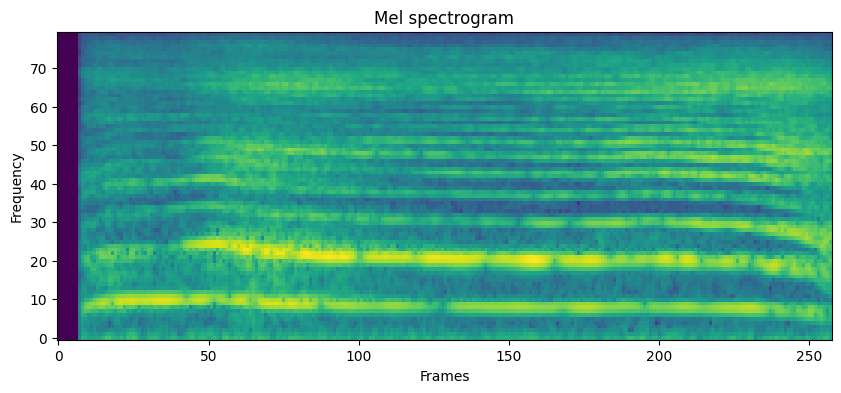

In [44]:
# Take a look at a sample record as an audio file and spectrogram
import random
sample_record_number = random.randint(0, len(data_tensors) - 1)
print("Cry Type: ", str(data_tensors[sample_record_number][data_tensor_index.CRY_TYPE]))
spec = data_tensors[sample_record_number][data_tensor_index.SPEC]
print("")

print("File: ", data_tensors[sample_record_number][data_tensor_index.FILE_NAME])
print("Spectrogram shape: ", spec.shape)
plot_spectogram(spec)
display_audio(data_tensors[sample_record_number][data_tensor_index.WAV])


Label: lo: 15609
Label: pn: 95
Label: dc: 10497
Label: dk: 5233
Label: hu: 13095
Label: ot: 76

Age: 0 to 4 weeks old: 13062
Age: 4 to 8 weeks old: 14203
Age: 2 to 6 months old: 17340
Age: 7 month to 2 years old: 0
Age: more than 2 years old: 0

Gender: m: 29666
Gender: f: 14939

Average Length:  1.5
Lowest Length:  1.5
Highest Length:  1.5



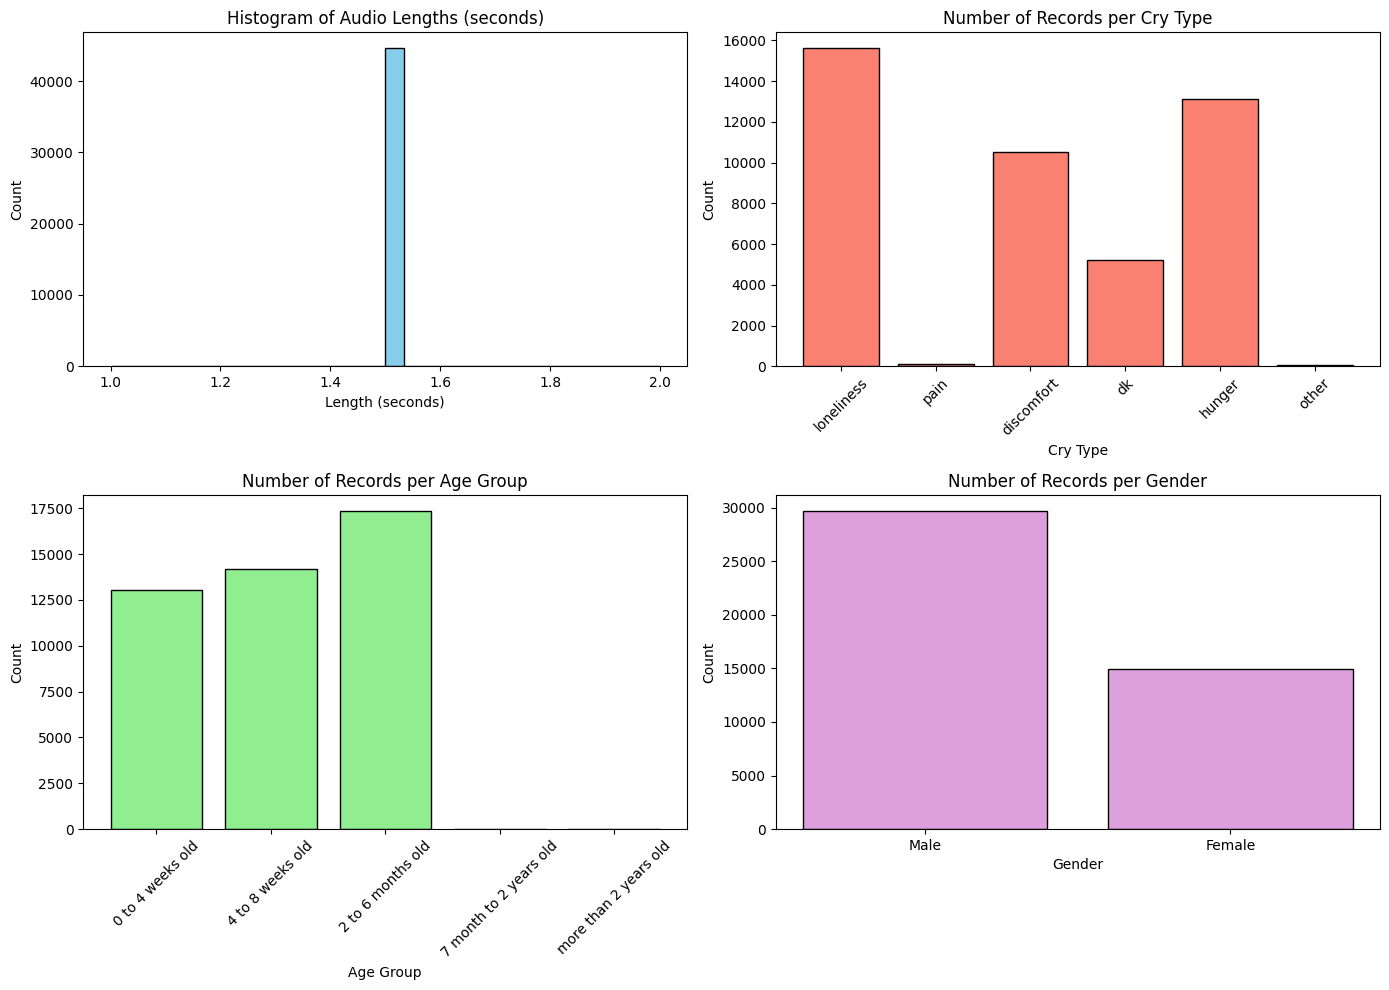

<module 'matplotlib.pyplot' from '/Users/robertjaret/Documents/Git/Capstone/.venv/lib/python3.14/site-packages/matplotlib/pyplot.py'>

In [45]:
analyze_data_tensors(data_tensors, label_set, True)

In [ ]:
# Data Synthesis and Augmentation Functions
import torch
import numpy as np

def mixup_data(x, y, alpha=0.2):
    '''Returns mixed inputs, pairs of targets, and lambda'''
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [46]:
# Filter / process data and create dataloaders for training, validation, and testing

# Filter to only include cry_types of loneliness, discomfort, and hunger 
# because they are most represented in the dataset and the original investigators limited
# their analysis to these cry types.
allowed_cry_types = {'lo', 'dc', 'hu'}
label_set_training = {label for label in label_set if label in allowed_cry_types}
label_to_idx = {label: i for i, label in enumerate(sorted(list(label_set_training)))}
data_tensors = [x for x in data_tensors if x[data_tensor_index.CRY_TYPE] in allowed_cry_types]

h["label_set_training"] = label_set_training

# Further filter to only ages 4-8 weeks ('48') and 2-6 months ('26')
allowed_ages = {'48', '26'}
data_tensors = [x for x in data_tensors if x[data_tensor_index.AGE] in allowed_ages]

# a lot of data, so rather than balancing by augmentation, we can just remove excess records 
# of loneliness (lo) and discomfort (dc) since they are overrepresented compared to hunger (hu)
h["balanced_cry_types"] = True
if h["balanced_cry_types"]:
    # make the crytypes have the same distribution by removing excess records of loneliness (lo) and discomfort (dc) since they are overrepresented compared to hunger (hu)
    from collections import Counter
    cry_type_counts = Counter(x[data_tensor_index.CRY_TYPE] for x in data_tensors)
    print("Cry type counts before balancing:", cry_type_counts)

    # Determine the minimum count among the allowed cry types
    min_count = min(cry_type_counts[cry_type] for cry_type in allowed_cry_types)

    # Balance the dataset by sampling min_count instances for each cry type
    balanced_data_tensors = []
    for cry_type in allowed_cry_types:
        cry_type_data = [x for x in data_tensors if x[data_tensor_index.CRY_TYPE] == cry_type]
        balanced_data_tensors.extend(cry_type_data[:min_count])

    data_tensors = balanced_data_tensors
    cry_type_counts = Counter(x[data_tensor_index.CRY_TYPE] for x in data_tensors)
    print("Cry type counts after balancing:", cry_type_counts)

from sklearn.utils import shuffle
data_tensors = shuffle(data_tensors,random_state=42)

train_size = int(len(data_tensors) * 0.75)
validate_size = int(len(data_tensors) * 0.15)  # Ensure total length matches
test_size = len(data_tensors) - (train_size + validate_size)

train_data, validate_data, test_data = torch.utils.data.random_split(data_tensors, [train_size, validate_size, test_size], generator=torch.Generator().manual_seed(42))

print("Training Data:")
analyze_data_tensors(train_data,label_set, False)
print("Validation Data:")
analyze_data_tensors(validate_data, label_set, False)
print("Test Data:")
analyze_data_tensors(test_data,label_set, False)

# splits seem to be representative of the overall datasets distributions

dataset_sizes = {'train': len(train_data),
                 'val': len(validate_data),
                 'test': len(test_data)}

h["dataset_size"] = len(data_tensors)
h["dataset_phase_sizes"] = dataset_sizes

print(dataset_sizes)

dataloaders = {
    'train': DataLoader(
        [
            # Spectrogram is currently (1, n_mels, time_steps). LSTM expects (time_steps, n_mels) per item.
            # Squeeze the first dimension and then permute.
            # Changed labels from one-hot to integer class indices for CrossEntropyLoss
            (x[data_tensor_index.SPEC].squeeze(0).permute(1,0), torch.tensor(label_to_idx[x[data_tensor_index.CRY_TYPE]], dtype=torch.long))
            for x in train_data
        ],
        batch_size=h["batch_size"],
        shuffle=True
    ),
    'val': DataLoader(
        [
            # Changed labels from one-hot to integer class indices for CrossEntropyLoss
            (x[data_tensor_index.SPEC].squeeze(0).permute(1,0), torch.tensor(label_to_idx[x[data_tensor_index.CRY_TYPE]], dtype=torch.long))
            for x in validate_data
        ],
        batch_size=h["batch_size"],
        shuffle=False
    ),
    'test': DataLoader(
        [
            # Changed labels from one-hot to integer class indices for CrossEntropyLoss
            (x[data_tensor_index.SPEC].squeeze(0).permute(1,0), torch.tensor(label_to_idx[x[data_tensor_index.CRY_TYPE]], dtype=torch.long))
            for x in test_data
        ],
        batch_size=h["batch_size"],
        shuffle=False
    )
}


Cry type counts before balancing: Counter({'lo': 11655, 'dc': 8870, 'hu': 7689})
Cry type counts after balancing: Counter({'lo': 7689, 'hu': 7689, 'dc': 7689})
Training Data:
Label: lo: 5813
Label: pn: 0
Label: dc: 5767
Label: dk: 0
Label: hu: 5720
Label: ot: 0

Age: 0 to 4 weeks old: 0
Age: 4 to 8 weeks old: 7652
Age: 2 to 6 months old: 9648
Age: 7 month to 2 years old: 0
Age: more than 2 years old: 0

Gender: m: 11791
Gender: f: 5509

Average Length:  1.5
Lowest Length:  1.5
Highest Length:  1.5

Validation Data:
Label: lo: 1122
Label: pn: 0
Label: dc: 1175
Label: dk: 0
Label: hu: 1163
Label: ot: 0

Age: 0 to 4 weeks old: 0
Age: 4 to 8 weeks old: 1509
Age: 2 to 6 months old: 1951
Age: 7 month to 2 years old: 0
Age: more than 2 years old: 0

Gender: m: 2384
Gender: f: 1076

Average Length:  1.5
Lowest Length:  1.5
Highest Length:  1.5

Test Data:
Label: lo: 754
Label: pn: 0
Label: dc: 747
Label: dk: 0
Label: hu: 806
Label: ot: 0

Age: 0 to 4 weeks old: 0
Age: 4 to 8 weeks old: 984
Age

## 🚩 MODEL DEFINITION CELL
This cell defines the neural network model architectures. Edit this cell to change the model structure or add new architectures.

In [67]:
## 🚩🚩🚩 MODEL DEFINITIONS 🚩🚩🚩

# Define the model as a custom nn.Module to handle LSTM output
class CryLSTMClassifier(nn.Module):
    def __init__(self, n_mels, num_classes):
        super(CryLSTMClassifier, self).__init__()
        self.model_name = "CryLSTMClassifier"
        self.lstm1 = nn.LSTM(input_size=h["n_mels"], hidden_size=128, batch_first=True, bidirectional=True)
        self.dropout1 = nn.Dropout(0.2)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=64, batch_first=True, bidirectional=True)
        self.dropout2 = nn.Dropout(0.2)
        self.linear1 = nn.Linear(128, 128)
        self.relu = nn.ReLU()
        self.dropout3 = nn.Dropout(0.3)
        self.linear2 = nn.Linear(128, num_classes)
        

    def forward(self, x):
        # LSTM layers return output and (h_n, c_n), we only need the output
        x, _ = self.lstm1(x)
        x = self.dropout1(x)
        x, _ = self.lstm2(x)
        x = self.dropout2(x)

        # Take the output of the last time step for classification
        # If batch_first is True, x has shape (batch, seq_len, num_directions * hidden_size)
        # We need the output of the last time step: x[:, -1, :]
        x = self.linear1(x[:, -1, :])
        x = self.relu(x)
        x = self.dropout3(x)
        x = self.linear2(x)
        return x
    
# Define the model as a custom nn.Module to handle LSTM output
class CryLSTMClassifierBatchNorm(nn.Module):
    def __init__(self, n_mels, num_classes, dropout=0.3):
        super(CryLSTMClassifierBatchNorm, self).__init__()
        self.model_name = "CryLSTMClassifierBatchNorm"
        self.lstm1 = nn.LSTM(input_size=h["n_mels"], hidden_size=128, batch_first=True, bidirectional=True)
        self.dropout1 = nn.Dropout(dropout)
        self.bn1 = nn.BatchNorm1d(256)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=64, batch_first=True, bidirectional=True)
        self.dropout2 = nn.Dropout(dropout)
        self.bn2 = nn.BatchNorm1d(128)
        self.linear1 = nn.Linear(128, 128)
        self.relu = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout)
        self.linear2 = nn.Linear(128, num_classes)
        

    def forward(self, x):
        # LSTM layers return output and (h_n, c_n), we only need the output
        x, _ = self.lstm1(x)

        # BatchNorm expects (batch, features, seq_len), so permute
        x = x.permute(0, 2, 1)
        x = self.bn1(x)
        x = x.permute(0, 2, 1)
        x, _ = self.lstm2(x)
        x = x.permute(0, 2, 1)
        x = self.bn2(x)
        x = x.permute(0, 2, 1)

        # Take the output of the last time step for classification
        # If batch_first is True, x has shape (batch, seq_len, num_directions * hidden_size)
        # We need the output of the last time step: x[:, -1, :]
        x = self.linear1(x[:, -1, :])
        x = self.relu(x)
        x = self.dropout3(x)
        x = self.linear2(x)
        return x
    
# Conv + LSTM classifier
class CryLSTMConvClassifier(nn.Module):
    def __init__(self, n_mels, num_classes, dropout=0.3):
        super(CryLSTMConvClassifier, self).__init__()
        self.model_name = "CryLSTMConvClassifier"
        # Conv2d expects input (batch, channels, n_mels, time_steps)
        self.conv = nn.Conv2d(1, 16, kernel_size=(3, 3), padding=(1, 1))
        self.bn_conv = nn.BatchNorm2d(16)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=(2, 2))
        
        # After pooling, n_mels and time_steps are halved
        # We'll flatten the conv output to (batch, time_steps, features) for LSTM
        self.lstm1 = nn.LSTM(input_size=(n_mels // 2) * 16, hidden_size=128, batch_first=True, bidirectional=True)
        self.dropout1 = nn.Dropout(dropout)
        self.bn1 = nn.BatchNorm1d(256)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=64, batch_first=True, bidirectional=True)
        self.dropout2 = nn.Dropout(dropout)
        self.bn2 = nn.BatchNorm1d(128)
        self.linear1 = nn.Linear(128, 128)
        self.dropout3 = nn.Dropout(dropout)
        self.linear2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: (batch, time_steps, n_mels)
        # Reshape to (batch, 1, n_mels, time_steps)
        x = x.permute(0, 2, 1).unsqueeze(1)
        x = self.conv(x)
        x = self.bn_conv(x)
        x = self.relu(x)
        x = self.pool(x)
        # x: (batch, channels=16, n_mels//2, time_steps//2)
        # Flatten for LSTM: (batch, time_steps//2, n_mels//2 * 16)
        b, c, n_mels_p, t_p = x.shape
        x = x.permute(0, 3, 1, 2).contiguous().view(b, t_p, c * n_mels_p)
        x, _ = self.lstm1(x)
        x = self.dropout1(x)
        x = x.permute(0, 2, 1)
        x = self.bn1(x)
        x = x.permute(0, 2, 1)
        x, _ = self.lstm2(x)
        x = self.dropout2(x)
        x = x.permute(0, 2, 1)
        x = self.bn2(x)
        x = x.permute(0, 2, 1)
        x = self.linear1(x[:, -1, :])
        x = self.relu(x)
        x = self.dropout3(x)
        x = self.linear2(x)
        return x

# Pure CNN classifier for spectrogram input (best pure CNN model)
class CryCNNClassifierComplex(nn.Module):
    def __init__(self, n_mels, num_classes, dropout=0.3):
        super(CryCNNClassifierComplex, self).__init__()
        self.model_name = "CryCNNClassifierComplex"
        self.conv1 = nn.Conv2d(1, 32, kernel_size=(3, 3), padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=(3, 3), padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(kernel_size=(2, 2))
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.flatten = nn.Flatten()
        self.fc1 = None  # Will be defined after seeing input shape
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: (batch, time_steps, n_mels)
        # Reshape to (batch, 1, n_mels, time_steps)
        x = x.permute(0, 2, 1).unsqueeze(1)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.pool(x)
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.pool(x)
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.pool(x)
        x = self.flatten(x)
        if self.fc1 is None:
            print(f"[DEBUG] Flattened shape: {x.shape}")
            self.fc1 = nn.Linear(x.shape[1], 128).to(x.device)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Pure CNN classifier with 6 conv layers and ReLU
class CryCNNClassifierComplex_6Conv(nn.Module):
    def __init__(self, n_mels, num_classes, dropout=0.3):
        super(CryCNNClassifierComplex_6Conv, self).__init__()
        self.model_name = "CryCNNClassifierComplex_6Conv"
        self.conv1 = nn.Conv2d(1, 32, kernel_size=(3, 3), padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=(3, 3), padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.conv5 = nn.Conv2d(256, 256, kernel_size=(3, 3), padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.conv6 = nn.Conv2d(256, 512, kernel_size=(3, 3), padding=1)
        self.bn6 = nn.BatchNorm2d(512)
        self.pool = nn.MaxPool2d(kernel_size=(2, 2))
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.flatten = nn.Flatten()
        self.fc1 = None  # Will be defined after seeing input shape
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: (batch, time_steps, n_mels)
        # Reshape to (batch, 1, n_mels, time_steps)
        x = x.permute(0, 2, 1).unsqueeze(1)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.pool(x)  # Pool after 2nd conv
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.pool(x)  # Pool after 4th conv
        x = self.conv5(x)
        x = self.bn5(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv6(x)
        x = self.bn6(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.pool(x)  # Pool after 6th conv
        x = self.flatten(x)
        if self.fc1 is None:
            print(f"[DEBUG] Flattened shape: {x.shape}")
            self.fc1 = nn.Linear(x.shape[1], 128).to(x.device)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Pure CNN classifier with 8 conv layers and ReLU
class CryCNNClassifierComplex_8Conv(nn.Module):
    def __init__(self, n_mels, num_classes, dropout=0.3):
        super(CryCNNClassifierComplex_8Conv, self).__init__()
        self.model_name = "CryCNNClassifierComplex_8Conv"
        self.conv1 = nn.Conv2d(1, 32, kernel_size=(3, 3), padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=(3, 3), padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.conv5 = nn.Conv2d(256, 256, kernel_size=(3, 3), padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.conv6 = nn.Conv2d(256, 512, kernel_size=(3, 3), padding=1)
        self.bn6 = nn.BatchNorm2d(512)
        self.conv7 = nn.Conv2d(512, 512, kernel_size=(3, 3), padding=1)
        self.bn7 = nn.BatchNorm2d(512)
        self.conv8 = nn.Conv2d(512, 1024, kernel_size=(3, 3), padding=1)
        self.bn8 = nn.BatchNorm2d(1024)
        self.pool = nn.MaxPool2d(kernel_size=(2, 2))
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.flatten = nn.Flatten()
        self.fc1 = None  # Will be defined after seeing input shape
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: (batch, time_steps, n_mels)
        # Reshape to (batch, 1, n_mels, time_steps)
        x = x.permute(0, 2, 1).unsqueeze(1)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.pool(x)  # Pool after 2nd conv
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.pool(x)  # Pool after 4th conv
        x = self.conv5(x)
        x = self.bn5(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv6(x)
        x = self.bn6(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.pool(x)  # Pool after 6th conv
        x = self.conv7(x)
        x = self.bn7(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv8(x)
        x = self.bn8(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.pool(x)  # Pool after 8th conv
        x = self.flatten(x)
        if self.fc1 is None:
            print(f"[DEBUG] Flattened shape: {x.shape}")
            self.fc1 = nn.Linear(x.shape[1], 128).to(x.device)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# CNN + LSTM classifier for spectrogram input (fixed: all layers in __init__)
import torch
import torch.nn as nn

class CryCNNLSTMClassifier(nn.Module):
    def __init__(self, n_mels, num_classes, dropout=0.3, lstm_hidden=128, lstm_layers=1):
        super().__init__()
        self.model_name = "CryCNNLSTMClassifier"
        self.conv1 = nn.Conv2d(1, 32, kernel_size=(3, 3), padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=(3, 3), padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(kernel_size=(2, 2))
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.lstm_hidden = lstm_hidden
        self.lstm_layers = lstm_layers
        # Calculate the feature size after convolutions and pooling
        # Each pooling halves the freq and time dims (4 times)
        freq_after = n_mels // (2 ** 4)
        cnn_feat_size = 256 * freq_after
        self.lstm = nn.LSTM(input_size=cnn_feat_size, hidden_size=lstm_hidden, num_layers=lstm_layers, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)
    def forward(self, x):
        # x: (batch, time_steps, n_mels)
        x = x.permute(0, 2, 1).unsqueeze(1)  # (batch, 1, n_mels, time_steps)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.pool(x)
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.pool(x)
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.pool(x)
        # x: (batch, channels=256, freq, time)
        b, c, f, t = x.shape
        x = x.permute(0, 3, 1, 2).contiguous()  # (batch, time, channels, freq)
        x = x.view(b, t, c * f)  # (batch, time, features)
        lstm_out, _ = self.lstm(x)  # (batch, time, hidden*2)
        x = lstm_out[:, -1, :]  # Take last time step
        x = self.dropout(x)
        x = self.fc(x)
        return x

# Utility: Save model and load model functions
def save_model(model, run_id):
    """Save the model's state_dict to models/modelname_runid."""
    model_dir = "models"
    os.makedirs(model_dir, exist_ok=True)
    model_name = h["model_name"]
    path = os.path.join(model_dir, f"{model_name}_{run_id}.pt")
    torch.save(model.state_dict(), path)
    print(f"Model saved to {path}")

def load_model(model_class, path, *args, **kwargs):
    """Instantiate model_class, load state_dict from path, and return the model."""
    model = model_class(*args, **kwargs)
    model.load_state_dict(torch.load(path, map_location='cpu'))
    print(f"Model loaded from {path}")
    return model


In [48]:
def train_model(model, dataloaders, dataset_sizes, criterion, optimizer, scheduler, num_epochs=25):
    import time, copy
    from sklearn.metrics import roc_auc_score
    from sklearn.preprocessing import label_binarize
    since = time.time()

    model = model.to(device)
    h["model_name"] = model.model_name
    h["run_time"] = time.strftime("%Y-%m-%d_%H-%M-%S")
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_auc = -1
    best_epoch = 0
    best_loss = float('inf')
    best_loss_epoch = 0
    best_acc = 0.0
    best_acc_epoch = 0
    phases = ['train', 'val', 'test']
    training_curves = {}
    
    for phase in phases:
        training_curves[phase+'_loss'] = []
        training_curves[phase+'_acc'] = []
        if phase != 'train':
            training_curves[phase+'_auc'] = []

    num_classes = len(label_to_idx)
    all_class_indices = list(range(num_classes))

    # Early stopping: track val AUC
    val_auc_history = []
    auc_decline_count = 0

    for epoch in range(h["num_epochs"]):
        print(f'\nEpoch {epoch+1}/{h["num_epochs"]}')
        print('-' * 10)

        stop_early = False
        for phase in phases:
            if phase == 'train':
                model.train()
            else:
                model.eval()
            running_loss = 0.0
            running_corrects = 0
            all_probs = []
            all_labels = []

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    _, predicted_class = torch.max(outputs, 1)
                    true_class = labels
                    correct_predictions = (predicted_class == true_class).sum()

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                        
                running_loss += loss.item() * inputs.size(0)
                running_corrects += correct_predictions.item()

                if phase != 'train':
                    probs = torch.softmax(outputs, dim=1)
                    all_probs.append(probs.detach().cpu().numpy())
                    all_labels.append(labels.detach().cpu().numpy())

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects / dataset_sizes[phase]
            training_curves[phase+'_loss'].append(epoch_loss)
            training_curves[phase+'_acc'].append(epoch_acc)

            # Track best loss for logging (on validation set)
            if phase == 'val' and epoch_loss < best_loss:
                best_loss = epoch_loss
                best_loss_epoch = epoch

            # Track best accuracy for logging (on validation set)
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_acc_epoch = epoch

            # Compute macro-averaged AUC for val/test
            if phase != 'train':
                import numpy as np
                all_probs_np = np.concatenate(all_probs, axis=0) if all_probs else None
                all_labels_np = np.concatenate(all_labels, axis=0) if all_labels else None
                unique_labels = np.unique(all_labels_np) if all_labels_np is not None else []
                
                auc = float('nan')
                if all_probs_np is not None and all_labels_np is not None:
                    if len(unique_labels) < 2:
                        print(f"AUC computation skipped: only one class present in {phase} at epoch {epoch+1}.")
                    else:
                        try:
                            all_labels_onehot = label_binarize(all_labels_np, classes=all_class_indices)
                           
                            if all_labels_onehot.shape[1] != all_probs_np.shape[1]:
                                print(f"Shape mismatch after padding: onehot labels shape {all_labels_onehot.shape}, probs shape {all_probs_np.shape}")
                                auc = float('nan')
                            else:
                                auc = roc_auc_score(all_labels_onehot, all_probs_np, average='macro', multi_class='ovr')
                        except Exception as e:
                            print(f"AUC computation failed: {e}")
                            auc = float('nan')
                else:
                    auc = float('nan')
                training_curves[phase+'_auc'].append(auc)
                print(f'{phase:5} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} AUC: {auc:.4f}')

                if phase == 'val':
                    # Early stopping logic: check if AUC has declined over 3 epochs
                    val_auc_history.append(auc)
                    if len(val_auc_history) > 3 and (val_auc_history[-1] < val_auc_history[-2]) and (val_auc_history[-2] < val_auc_history[-3]) and (val_auc_history[-3] < val_auc_history[-4]):
                        print(f"Validation AUC has declined over 3 or more epochs. Stopping early at epoch {epoch+1}.")
                        stop_early = True

                if phase == 'val' and auc is not None and auc > best_auc:
                    best_epoch = epoch
                    best_auc = auc
                    best_model_wts = copy.deepcopy(model.state_dict())
            else:
                print(f'{phase:5} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if stop_early:
            h["early_stopping_epoch"] = epoch + 1
            break

    time_elapsed = time.time() - since
    print(f'\nTraining complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val AUC: {best_auc:.4f} at epoch {best_epoch + 1}')
    print(f'Best val Loss: {best_loss:.4f} at epoch {best_loss_epoch + 1}')
    print(f'Best val Acc: {best_acc:.4f} at epoch {best_acc_epoch + 1}')
    
    # Store training duration in h
    h["training_duration_seconds"] = time_elapsed
    
    # Capture for logging
    h["best_auc"] = best_auc
    h["best_epoch"] = best_epoch
    h["best_loss"] = best_loss
    h["best_loss_epoch"] = best_loss_epoch
    h["best_acc"] = best_acc
    h["best_acc_epoch"] = best_acc_epoch
    model.load_state_dict(best_model_wts)

    return model, training_curves


In [ ]:
## 🚩🚩🚩 MODEL TRAINING CELL 🚩🚩🚩
# This cell instantiates the model, optimizer, and loss function, and runs the main training loop. 
# Edit this cell to change model architecture, optimizer, or training parameters.

import collections 

h["class_weighting_on"] = False
h["focal_loss_on"] = False

# # Calculate class weights for imbalanced dataset
if h["class_weighting_on"] == True:
    class_counts = collections.Counter([x[data_tensor_index.CRY_TYPE] for x in train_data])
    total_samples = sum(class_counts.values())
    class_weights = torch.zeros(len(h["label_set_training"]))

    for label, idx in label_to_idx.items():
        class_weights[idx] = total_samples / class_counts[label]
    class_weights = class_weights / class_weights.sum() # Normalize weights

    # # Ensure weights are on the correct device
    class_weights = class_weights.to(device)

# Instantiate the custom model
h["dropout"] = 0.2
h["run_desc"] = "CNN with LSTM didn't perform well. Going to give it a shot with a bigger hidden length (256)."
model = CryCNNClassifierComplex(h["n_mels"], len(label_to_idx), dropout=h["dropout"], lstm_hidden=256).to(device)


# Assume model is your nn.Module instance
optimizer = torch.optim.Adam(model.parameters(), lr=h["learning_rate"], weight_decay=h["weight_decay"])  # L2 regularization via weight_decay
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.01)

if h["focal_loss_on"] == True:

    # Use CrossEntropyFocalLoss from pytorch_toolbelt
    from pytorch_toolbelt.losses import CrossEntropyFocalLoss
    # gamma=2.0 is a common default; adjust as needed
    if h["class_weighting_on"] == True:
        criterion = CrossEntropyFocalLoss(class_weights=class_weights, gamma=2.0, reduction='mean')
    else:
        criterion = CrossEntropyFocalLoss(gamma=2.0, reduction='mean')

elif h["class_weighting_on"] == True:
    criterion = nn.CrossEntropyLoss(weight=class_weights)
else:
    criterion = nn.CrossEntropyLoss()

h["num_epochs"] = 20

model, training_curves = train_model(model, dataloaders, dataset_sizes, criterion, optimizer, scheduler, h["num_epochs"])



Epoch 1/20
----------
train Loss: 1.1076 Acc: 0.3347
val   Loss: 1.1058 Acc: 0.3275 AUC: 0.5272
test  Loss: 1.1055 Acc: 0.3299 AUC: 0.5263

Epoch 2/20
----------
train Loss: 1.1031 Acc: 0.3447
val   Loss: 1.1058 Acc: 0.3436 AUC: 0.5504
test  Loss: 1.1115 Acc: 0.3251 AUC: 0.5508

Epoch 3/20
----------
train Loss: 1.0934 Acc: 0.3714
val   Loss: 1.0829 Acc: 0.3480 AUC: 0.6056
test  Loss: 1.0868 Acc: 0.3407 AUC: 0.6023

Epoch 4/20
----------
train Loss: 1.0836 Acc: 0.3910
val   Loss: 1.0692 Acc: 0.4165 AUC: 0.6123
test  Loss: 1.0719 Acc: 0.4105 AUC: 0.6111

Epoch 5/20
----------
train Loss: 1.0716 Acc: 0.4143
val   Loss: 1.0691 Acc: 0.4176 AUC: 0.6293
test  Loss: 1.0735 Acc: 0.4088 AUC: 0.6247

Epoch 6/20
----------
train Loss: 1.0495 Acc: 0.4422
val   Loss: 1.0449 Acc: 0.4613 AUC: 0.6558
test  Loss: 1.0459 Acc: 0.4491 AUC: 0.6486

Epoch 7/20
----------
train Loss: 1.0316 Acc: 0.4639
val   Loss: 1.0252 Acc: 0.4720 AUC: 0.6723
test  Loss: 1.0342 Acc: 0.4582 AUC: 0.6605

Epoch 8/20
--------

KeyboardInterrupt: 

In [59]:
def plot_training_curves_and_confusion(training_curves, model, dataloader, label_to_idx, idx_to_label, device='cpu',
                         phases=['train', 'val', 'test'],
                         metrics=['loss','acc', 'auc']):
    import math
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt
    
    epochs = list(range(len(training_curves['train_loss'])))

    num_metrics = len(metrics)
    ncols = 2
    nrows = math.ceil((num_metrics + 1) / ncols)  # +1 for confusion matrix
    fig, axs = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
    axs = axs.flatten() if (num_metrics + 1) > 1 else [axs]

    # Plot training curves
    for i, metric in enumerate(metrics):
        ax = axs[i]
        ax.set_title(f'Training curves - {metric}')
        for phase in phases:
            key = phase+'_'+metric
            if key in training_curves:
                ax.plot(epochs, training_curves[key], label=phase)
        ax.set_xlabel('epoch')
        ax.legend()

    # Plot confusion matrix in the last subplot
    ax_cm = axs[num_metrics]
    model.eval()
    all_preds = []
    all_actual = []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_actual.extend(labels.cpu().numpy())
    all_class_indices = list(idx_to_label.keys())
    cm = confusion_matrix(all_actual, all_preds, labels=all_class_indices)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[idx_to_label[i] for i in all_class_indices])
    disp.plot(ax=ax_cm, cmap='Blues', xticks_rotation=45)
    ax_cm.set_title('Confusion Matrix')
    
    # Hide any unused subplots
    for j in range(num_metrics + 1, len(axs)):
        fig.delaxes(axs[j])
    plt.tight_layout()
    
    plt.show()  # Do not show here, return fig instead
    return fig


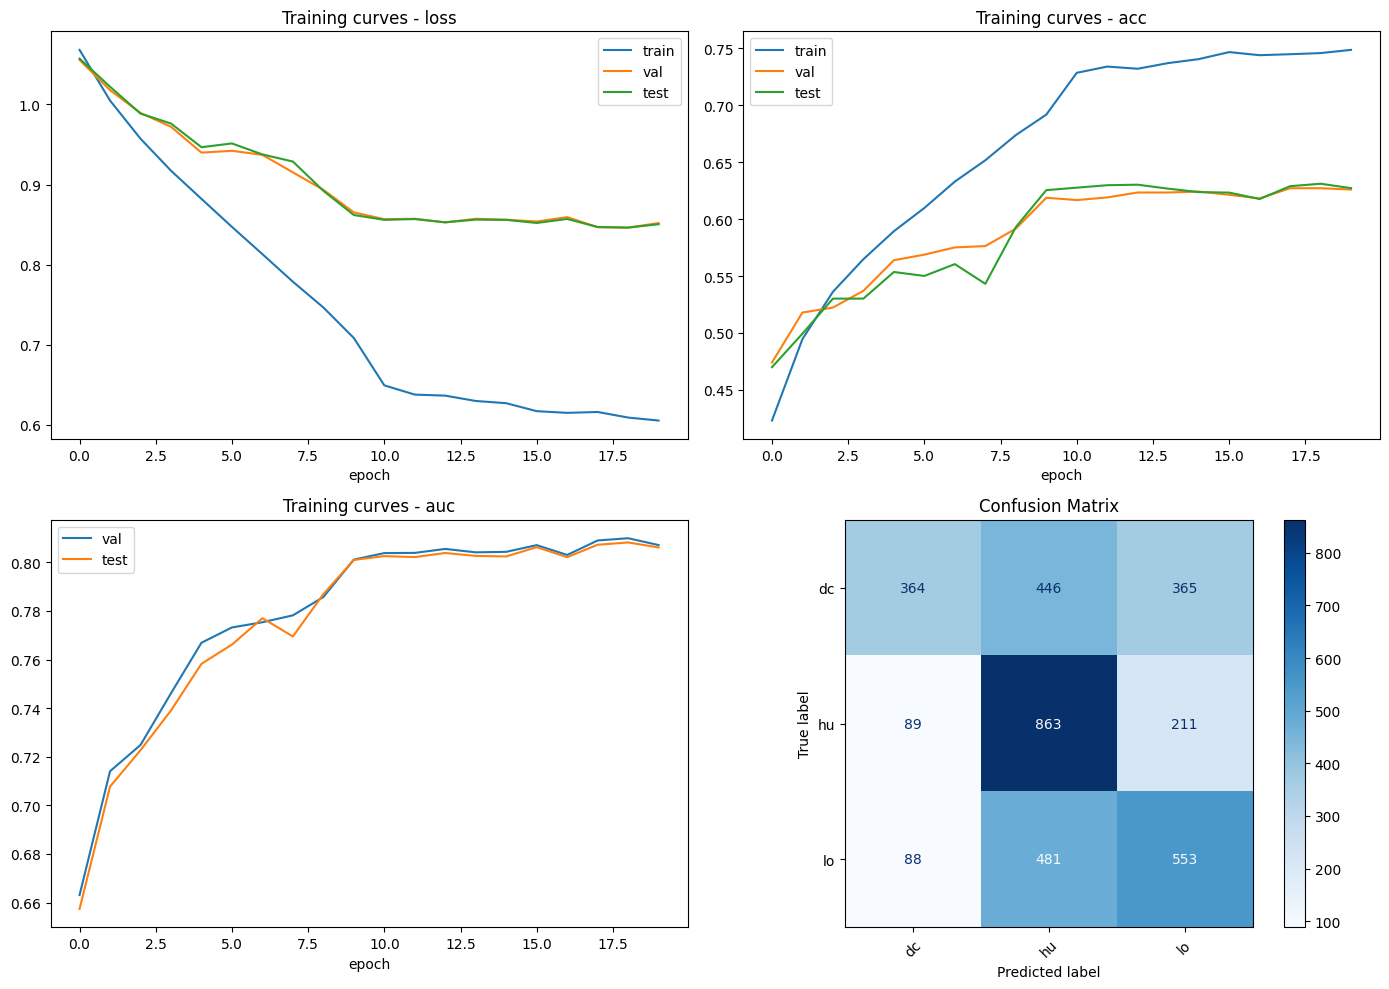

In [73]:
idx_to_label = {v: k for k, v in label_to_idx.items()}
fig = plot_training_curves_and_confusion(training_curves, model, dataloaders['val'], label_to_idx, idx_to_label, device, phases=['train', 'val', 'test'])


In [ ]:
# Logging for run comparison
from time import time

def append_run_metrics_csv(
    history,
    run_log_path="run_comparison.csv",
    fig=None,
    save_model=False,
):
    import pandas as pd
    from pathlib import Path
    
    output_path = Path(run_log_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if not history:
        raise ValueError(
            "Training history is empty."
        )

    run_id = 1
    if output_path.exists():
        run_log_df = pd.read_csv(output_path)
        if 'run_id' in run_log_df.columns and not run_log_df.empty:
            run_id = int(run_log_df['run_id'].max()) + 1
        else:
            run_id = 1
    else:
        run_log_df = None
        run_id = 1
    
    run_id = int(run_id)
    history["run_id"] = run_id
    new_row_df = pd.DataFrame([history])

    # Desired column order
    desired_cols = [
        'run_id', 'model_name', 'dataset_name', 'num_epochs', 'learning_rate', 'batch_size', 'dataset_size', 'dataset_phase_sizes',
        'best_auc', 'best_epoch', 'best_acc', 'best_acc_epoch', 'best_loss', 'best_loss_epoch', 'dropout', 'device', 'training_duration_seconds'
    ]
    # Add any other columns at the end
    all_cols = list(new_row_df.columns)
    extra_cols = [col for col in all_cols if col not in desired_cols]
    final_cols = desired_cols + extra_cols
    new_row_df = new_row_df.reindex(columns=final_cols)

    if run_log_df is not None:
        run_log_df = pd.concat([run_log_df, new_row_df], ignore_index=True)

        # Ensure column order
        all_cols = list(run_log_df.columns)
        extra_cols = [col for col in all_cols if col not in desired_cols]
        final_cols = desired_cols + extra_cols
        run_log_df = run_log_df.reindex(columns=final_cols)
    else:
        run_log_df = new_row_df

    run_log_df.to_csv(output_path, index=False)

    print(f"Saved run metrics to: {output_path}")

    # --- Save training curves and confusion matrix as image ---
    model_name = history.get("model_name", "model")
    if fig is not None:
        fig_filename = f"train_conf_{model_name}_run-{run_id}.png"
        fig_path = output_path.parent / "figures" / fig_filename
        fig_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(fig_path)
        print(f"Saved training curves and confusion matrix to: {fig_path}")

    if save_model:
        model_path = Path('models/')
        model_path.mkdir(parents=True, exist_ok=True)
        model_filename = f"{model_name}_run-{run_id}.pt"
        model_save_path = model_path / model_filename
        torch.save(model.state_dict(), model_save_path)
        print(f"Saved model state dict to: {model_save_path}")
    
    return run_log_df

append_run_metrics_csv(h, "infant_cries_run_comparison.csv", fig=fig, save_model=True)
# Prediction with 'I don't know' option using confidence threshold
def predict_with_idk(model, inputs, threshold=0.6, idk_label='I_dont_know'):
    model.eval()
    with torch.no_grad():
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        max_probs, preds = torch.max(probs, dim=1)
        preds_with_idk = []
        for prob, pred in zip(max_probs, preds):
            if prob.item() < threshold:
                preds_with_idk.append(idk_label)
            else:
                preds_with_idk.append(pred.item())  # or use idx_to_label[pred.item()]
    return preds_with_idk

Saved run metrics to: infant_cries_run_comparison.csv
Saved training curves and confusion matrix to: figures/train_conf_CryCNNLSTMClassifier_run-51.png
Saved model state dict to: models/CryCNNLSTMClassifier_run-51.pt


,run_id,model_name,dataset_name,num_epochs,learning_rate,batch_size,dataset_size,dataset_phase_sizes,best_auc,best_epoch,...,mel_fmin,mel_fmax,label_set_training,class_weighting_on,flocal_loss_on,focal_loss_on,balanced_cry_types,early_stopping_epoch,run_desc,run_time
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,CryLSTMClassifier,EnesBabyCries1B,10.0,0.001,50.0,28214.0,"{'train': 21160, 'val': 4232, 'test': 2822}",0.541501,0.0,...,20.0,8000.0,"{'dc', 'lo', 'hu'}",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,CryLSTMClassifierB,EnesBabyCries1B,10.0,0.001,50.0,28214.0,"{'train': 21160, 'val': 4232, 'test': 2822}",0.660369,9.0,...,20.0,8000.0,"{'dc', 'lo', 'hu'}",NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,47.0,CryCNNClassifierComplex,EnesBabyCries1B,20.0,0.001,30.0,23067.0,"{'train': 17300, 'val': 3460, 'test': 2307}",0.798222,19.0,...,120.0,11025.0,"{'lo', 'hu', 'dc'}",False,NaN,False,True,NaN,Raising weight_decay of L2 to see if it reduce...,2026-05-21_11-14-13
57,48.0,CryCNNClassifierComplex,EnesBabyCries1B,20.0,0.001,30.0,23067.0,"{'train': 17300, 'val': 3460, 'test': 2307}",0.809900,18.0,...,120.0,11025.0,"{'lo', 'hu', 'dc'}",False,NaN,False,True,NaN,Raising weight_decay of L2 to see if it reduce...,2026-05-21_11-44-14
58,49.0,CryCNNLSTMClassifier,EnesBabyCries1B,20.0,0.001,30.0,23067.0,"{'train': 17300, 'val': 3460, 'test': 2307}",0.809900,18.0,...,120.0,11025.0,"{'lo', 'hu', 'dc'}",False,NaN,False,True,NaN,First run of our winning CNN classifer with an...,2026-05-21_12-18-04
59,50.0,CryCNNLSTMClassifier,EnesBabyCries1B,20.0,0.001,30.0,23067.0,"{'train': 17300, 'val': 3460, 'test': 2307}",0.809900,18.0,...,120.0,11025.0,"{'lo', 'hu', 'dc'}",False,NaN,False,True,NaN,CNN with LSTM didn't perform well. Going to gi...,2026-05-21_12-33-40
